In [1]:
# Ячейка 1: Импорт библиотек
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import cv2
from pathlib import Path
import warnings
import datetime
from typing import List, Dict, Any, Optional, Tuple
import onnxruntime as ort
import os

warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


In [9]:
def safe_imread(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл не существует: {image_path}")
    
    # Пробуем прочитать с cv2
    image = cv2.imread(image_path)
    if image is not None:
        return image
    
    # Если cv2 не смог, пробуем альтернативные методы
    try:
        from PIL import Image
        import numpy as np
        pil_image = Image.open(image_path)
        image = np.array(pil_image)
        # Конвертируем RGB в BGR для совместимости с OpenCV
        if len(image.shape) == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        return image
    except Exception as e:
        print(f"PIL также не смог открыть файл: {e}")
        return None

In [ ]:
# Ячейка 2: Класс TreeClassifier
class TreeClassifier:
    def __init__(
        self,
        tree_type_classifier: str,
        multi_classifier: str,
        device: str = "cpu",
        input_size: int = 320
    ):
        """
        Классификатор деревьев
        
        Args:
            tree_type_classifier: путь к ONNX модели классификации типа дерева
            multi_classifier: путь к ONNX модели мультиклассовой классификации
            device: устройство для выполнения (cpu/cuda)
            input_size: размер входного изображения
        """
        self.tree_type_classifier = ort.InferenceSession(
            tree_type_classifier, 
            providers=["CPUExecutionProvider"]
        )
        self.multi_classifier = ort.InferenceSession(
            multi_classifier, 
            providers=["CPUExecutionProvider"]
        )
        self.device = device
        self.input_size = input_size
        
        # Получаем имена входов и выходов
        self.tree_type_input_name = self.tree_type_classifier.get_inputs()[0].name
        self.multi_classifier_input_name = self.multi_classifier.get_inputs()[0].name
        
        self.tree_type_output_names = [o.name for o in self.tree_type_classifier.get_outputs()]
        self.multi_classifier_output_names = [o.name for o in self.multi_classifier.get_outputs()]
        
        print(f"Инициализирован классификатор деревьев")
        print(f"Входной размер: {input_size}x{input_size}")
        print(f"Выходы tree_type: {self.tree_type_output_names}")
        print(f"Выходы multi_classifier: {self.multi_classifier_output_names}")

    @staticmethod
    def softmax(x: np.ndarray) -> np.ndarray:
        x = np.array(x, dtype=np.float64)
        if x.ndim == 1:
            x = x - np.max(x)
            e = np.exp(x)
            return (e / e.sum()).astype(np.float32)
        else:
            x = x - np.max(x, axis=-1, keepdims=True)
            e = np.exp(x)
            return (e / e.sum(axis=-1, keepdims=True)).astype(np.float32)

    def preprocess_image(self, image: np.ndarray) -> np.ndarray:
        """
        Предобработка изображения для классификации
        """
        # Конвертируем в RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Ресайз
        image_resized = cv2.resize(
            image_rgb, 
            (self.input_size, self.input_size), 
            interpolation=cv2.INTER_LINEAR
        )
        
        # Нормализация
        image_processed = image_resized.astype(np.float32) / 255.0
        
        # Стандартная нормализация для ImageNet
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        image_processed = (image_processed - mean[None, None, :]) / std[None, None, :]
        
        # Транспонирование в формат CHW
        image_processed = np.transpose(image_processed, (2, 0, 1))
        image_processed = np.expand_dims(image_processed, axis=0)
        
        return np.ascontiguousarray(image_processed.astype(np.float32))

    def classify_single_image(self, image_path: str) -> Dict[str, Any]:
        """
        Классификация одного изображения
        """
        start_time = datetime.datetime.now()
        
        # Загрузка изображения
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Изображение не найдено: {image_path}")
            
        image = safe_imread(image_path)
        if image is None:
            print(f"Не удалось прочитать изображение: {image_path}")
        
        # Предобработка
        processed_image = self.preprocess_image(image)
        
        try:
            # Классификация типа дерева
            tree_type_outputs = self.tree_type_classifier.run(
                None, 
                {self.tree_type_input_name: processed_image}
            )
            
            # Мультиклассовая классификация
            multi_class_outputs = self.multi_classifier.run(
                None, 
                {self.multi_classifier_input_name: processed_image}
            )
            
        except Exception as e:
            raise RuntimeError(f"Ошибка inference ONNX: {e}")
        
        # Словарь для маппинга классов
        mapping_dict = {
            'tree_type': {
                0: 'Береза', 1: 'Боярышник', 2: 'Вяз', 3: 'Дерен Белый', 4: 'Дуб',
                5: 'Ель', 6: 'Ива', 7: 'Карагана древовидная', 8: 'Кизильник', 9: 'Клен',
                10: 'Лапчатка Кустарниковая', 11: 'Лещина', 12: 'Липа', 13: 'Лиственница',
                14: 'Осина', 15: 'Пузыреплодник калинолистный', 16: 'Роза Морщинистая',
                17: 'Рябина', 18: 'Сирень Обыкновенная', 19: 'Сосна', 20: 'Спирея',
                21: 'Туя', 22: 'Чубушник', 23: 'Ясень'
            },
            'has_hollow': {0: 'No', 1: 'Yes'},
            'has_cracks': {0: 'No', 1: 'Yes'},
            'has_fruits_or_flowers': {0: 'No', 1: 'Yes'},
            'has_rot': {0: 'No', 1: 'Yes'},
            'has_trunk_damage': {0: 'No', 1: 'Yes'},
            'has_crown_damage': {0: 'No', 1: 'Yes'},
            'dry_branch_percentage': {0: '<50%', 1: '>50%'},
            'overall_condition': {0: '', 1: 'Аварийное', 2: 'Нездоровое', 3: 'Нормальное', 4: 'Опасное', 5: 'Хорошее'}
        }
        
        # Обработка результатов
        classification_result = {}
        
        # Обработка выхода классификации типа дерева
        for j, output_name in enumerate(self.tree_type_output_names):
            pred = tree_type_outputs[j]
            pred_vec = pred[0] if pred.ndim == 2 else pred
            class_id = int(np.argmax(pred_vec))
            confidence = float(np.max(self.softmax(pred_vec)))
            
            classification_result[output_name] = {
                "class_label": mapping_dict.get(output_name, {}).get(class_id, str(class_id)),
                "confidence": confidence,
                "class_id": class_id
            }
        
        # Обработка выхода мультиклассового классификатора
        for j, output_name in enumerate(self.multi_classifier_output_names):
            pred = multi_class_outputs[j]
            pred_vec = pred[0] if pred.ndim == 2 else pred
            class_id = int(np.argmax(pred_vec))
            confidence = float(np.max(self.softmax(pred_vec)))
            
            classification_result[output_name] = {
                "class_label": mapping_dict.get(output_name, {}).get(class_id, str(class_id)),
                "confidence": confidence,
                "class_id": class_id
            }
        
        processing_time = (datetime.datetime.now() - start_time).total_seconds()
        
        return {
            "image_path": image_path,
            "classification": classification_result,
            "processing_time_seconds": processing_time,
            "timestamp": start_time.isoformat()
        }

    def classify_batch(self, image_paths: List[str]) -> List[Dict[str, Any]]:
        """
        Классификация батча изображений
        """
        results = []
        
        for image_path in image_paths:
            try:
                result = self.classify_single_image(image_path)
                results.append(result)
                print(f"Обработано: {image_path}")
            except Exception as e:
                print(f"Ошибка при обработке {image_path}: {e}")
                continue
        
        return results

print("Класс TreeClassifier загружен успешно!")

Класс TreeClassifier загружен успешно!


In [11]:
# Ячейка 3: Тестирование классификатора на одном изображении
# Укажите пути к вашим моделям и тестовому изображению
TEST_IMAGE_PATH = r"C:\Users\shari\OneDrive\Рабочий стол\photo_2025-10-18_20-16-57.jpg"  # Замените на реальный путь
TREE_TYPE_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_tree_type_apple_vit_0.35\APPLE_XS_TRANSFORMER_TREE_TYPE_WEB_DATA.onnx"  # Замените на реальный путь
MULTI_CLASS_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_all_classes_53\simple_model.onnx"  # Замените на реальный путь

# Инициализация классификатора
try:
    classifier = TreeClassifier(
        tree_type_classifier=TREE_TYPE_MODEL,
        multi_classifier=MULTI_CLASS_MODEL,
        input_size=320,
        device="cpu"
    )
    print("Классификатор инициализирован успешно!")
    
    # Тест на одном изображении
    if os.path.exists(TEST_IMAGE_PATH):
        result = classifier.classify_single_image(TEST_IMAGE_PATH)
        print("Результат классификации одного изображения:")
        print(json.dumps(result, indent=2, ensure_ascii=False))
    else:
        print(f"Тестовое изображение не найдено: {TEST_IMAGE_PATH}")
        
except Exception as e:
    print(f"Ошибка при инициализации классификатора: {e}")

Инициализирован классификатор деревьев
Входной размер: 320x320
Выходы tree_type: ['tree_type']
Выходы multi_classifier: ['has_hollow', 'has_cracks', 'has_fruits_or_flowers', 'overall_condition', 'has_crown_damage', 'has_trunk_damage', 'has_rot']
Классификатор инициализирован успешно!
Результат классификации одного изображения:
{
  "image_path": "C:\\Users\\shari\\OneDrive\\Рабочий стол\\photo_2025-10-18_20-16-57.jpg",
  "classification": {
    "tree_type": {
      "class_label": "Осина",
      "confidence": 0.6661701202392578,
      "class_id": 14
    },
    "has_hollow": {
      "class_label": "No",
      "confidence": 0.8225024938583374,
      "class_id": 0
    },
    "has_cracks": {
      "class_label": "No",
      "confidence": 0.6340168714523315,
      "class_id": 0
    },
    "has_fruits_or_flowers": {
      "class_label": "No",
      "confidence": 0.8151186108589172,
      "class_id": 0
    },
    "overall_condition": {
      "class_label": "Нормальное",
      "confidence": 0.38

In [12]:
# Ячейка 4: Класс TreeClassificationAnalyzer
class TreeClassificationAnalyzer:
    def __init__(self, classifier: TreeClassifier):
        """
        Анализатор результатов классификации деревьев
        
        Args:
            classifier: инициализированный классификатор деревьев
        """
        self.classifier = classifier
        self.results_df = None
        self.predictions = []
        self.true_labels = []
        
    def load_and_process_dataset(self, json_path: str) -> pd.DataFrame:
        """
        Загрузка и обработка датасета из JSON
        
        Args:
            json_path: путь к JSON файлу с данными
            
        Returns:
            DataFrame с результатами
        """
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Извлекаем пути к изображениям и истинные метки
        image_paths = []
        true_labels = []
        
        for item in data:
            if 'image' in item and 'tree_type' in item:
                image_paths.append(item['image'])
                true_labels.append(item['tree_type'])
        
        print(f"Загружено {len(image_paths)} изображений для классификации")
        
        # Запускаем классификацию
        self.predictions = self.classifier.classify_batch(image_paths)
        self.true_labels = true_labels
        
        # Создаем DataFrame с результатами
        results_data = []
        for i, pred in enumerate(self.predictions):
            if i < len(self.true_labels):
                true_label = self.true_labels[i]
                pred_label = pred['classification']['tree_type']['class_label']
                confidence = pred['classification']['tree_type']['confidence']
                
                results_data.append({
                    'image_path': pred['image_path'],
                    'true_label': true_label,
                    'predicted_label': pred_label,
                    'confidence': confidence,
                    'is_correct': true_label == pred_label,
                    'processing_time': pred['processing_time_seconds']
                })
        
        self.results_df = pd.DataFrame(results_data)
        print(f"Создан DataFrame с {len(self.results_df)} записями")
        return self.results_df
    
    

print("Класс TreeClassificationAnalyzer загружен успешно!")

Класс TreeClassificationAnalyzer загружен успешно!


In [13]:
# Ячейка 5: Методы визуализации анализатора
# Добавляем методы к классу TreeClassificationAnalyzer

def _plot_overall_accuracy(self):
    """Визуализация общей точности"""
    accuracy = accuracy_score(self.results_df['true_label'], self.results_df['predicted_label'])
    total_images = len(self.results_df)
    
    plt.figure(figsize=(8, 6))
    plt.pie([accuracy, 1-accuracy], 
            labels=[f'Правильные\n{accuracy:.1%}', f'Ошибки\n{1-accuracy:.1%}'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
    plt.title(f'Общая точность классификации\n({total_images} изображений)')
    plt.show()

def _plot_confusion_matrix(self):
    """Матрица ошибок"""
    cm = confusion_matrix(self.results_df['true_label'], self.results_df['predicted_label'])
    classes = sorted(self.results_df['true_label'].unique())
    
    # Нормализация
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
               xticklabels=classes, yticklabels=classes)
    plt.title('Матрица ошибок (нормализованная)')
    plt.xlabel('Предсказанные классы')
    plt.ylabel('Истинные классы')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def _plot_class_accuracy(self):
    """Точность по классам"""
    class_accuracy = self.results_df.groupby('true_label').apply(
        lambda x: (x['true_label'] == x['predicted_label']).mean()
    ).sort_values()
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(class_accuracy)), class_accuracy.values, color='skyblue')
    plt.yticks(range(len(class_accuracy)), class_accuracy.index)
    plt.xlabel('Точность')
    plt.title('Точность по классам деревьев')
    plt.grid(axis='x', alpha=0.3)
    
    # Добавление значений на столбцы
    for i, acc in enumerate(class_accuracy.values):
        plt.text(acc + 0.01, i, f'{acc:.1%}', va='center')
    
    plt.tight_layout()
    plt.show()

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_overall_accuracy = _plot_overall_accuracy
TreeClassificationAnalyzer._plot_confusion_matrix = _plot_confusion_matrix
TreeClassificationAnalyzer._plot_class_accuracy = _plot_class_accuracy

print("Методы визуализации добавлены успешно!")

Методы визуализации добавлены успешно!


In [14]:
# Ячейка 6: Дополнительные методы визуализации
def _plot_confidence_distribution(self):
    """Распределение уверенности модели"""
    plt.figure(figsize=(10, 6))
    plt.hist(self.results_df['confidence'], bins=20, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Уверенность модели')
    plt.ylabel('Количество изображений')
    plt.title('Распределение уверенности модели')
    plt.grid(alpha=0.3)
    
    mean_confidence = self.results_df['confidence'].mean()
    plt.axvline(mean_confidence, color='red', linestyle='--', 
               label=f'Среднее: {mean_confidence:.3f}')
    plt.legend()
    plt.show()

def _plot_class_distribution(self):
    """Сравнение распределения классов в данных"""
    true_dist = Counter(self.results_df['true_label'])
    pred_dist = Counter(self.results_df['predicted_label'])
    
    all_classes = sorted(set(list(true_dist.keys()) + list(pred_dist.keys())))
    true_counts = [true_dist.get(cls, 0) for cls in all_classes]
    pred_counts = [pred_dist.get(cls, 0) for cls in all_classes]
    
    x = np.arange(len(all_classes))
    width = 0.35
    
    plt.figure(figsize=(15, 8))
    plt.bar(x - width/2, true_counts, width, label='Истинное', alpha=0.7)
    plt.bar(x + width/2, pred_counts, width, label='Предсказанное', alpha=0.7)
    
    plt.xlabel('Классы деревьев')
    plt.ylabel('Количество')
    plt.title('Распределение классов')
    plt.xticks(x, all_classes, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def _plot_processing_time(self):
    """Распределение времени обработки"""
    plt.figure(figsize=(10, 6))
    plt.hist(self.results_df['processing_time'], bins=20, alpha=0.7, color='green', edgecolor='black')
    plt.xlabel('Время обработки (секунды)')
    plt.ylabel('Количество изображений')
    plt.title('Распределение времени обработки')
    plt.grid(alpha=0.3)
    
    mean_time = self.results_df['processing_time'].mean()
    plt.axvline(mean_time, color='red', linestyle='--', 
               label=f'Среднее: {mean_time:.3f}с')
    plt.legend()
    plt.show()

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_confidence_distribution = _plot_confidence_distribution
TreeClassificationAnalyzer._plot_class_distribution = _plot_class_distribution
TreeClassificationAnalyzer._plot_processing_time = _plot_processing_time

print("Дополнительные методы визуализации добавлены успешно!")

Дополнительные методы визуализации добавлены успешно!


In [15]:
# Ячейка 7: Методы анализа ошибок и отчетов
def _plot_top_errors(self):
    """Анализ самых частых ошибок"""
    errors = self.results_df[self.results_df['true_label'] != self.results_df['predicted_label']]
    
    if errors.empty:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, 'Нет ошибок для анализа!', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Топ ошибок')
        plt.show()
        return
    
    error_pairs = errors.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
    top_errors = error_pairs.nlargest(8, 'count')
    
    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(top_errors)), top_errors['count'])
    plt.yticks(range(len(top_errors)), 
              [f"{row['true_label']} → {row['predicted_label']}" for _, row in top_errors.iterrows()])
    plt.xlabel('Количество ошибок')
    plt.title('Топ-8 самых частых ошибок')
    plt.grid(axis='x', alpha=0.3)
    
    for bar, count in zip(bars, top_errors['count']):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{count}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()

def generate_detailed_report(self) -> Dict[str, Any]:
    """Генерация детального текстового отчета"""
    if self.results_df is None:
        return {"error": "Данные не загружены"}
    
    accuracy = accuracy_score(self.results_df['true_label'], self.results_df['predicted_label'])
    total_images = len(self.results_df)
    unique_classes = len(self.results_df['true_label'].unique())
    
    # Метрики по классам
    class_report = classification_report(self.results_df['true_label'], 
                                       self.results_df['predicted_label'], 
                                       output_dict=True)
    
    # Анализ уверенности
    mean_confidence = self.results_df['confidence'].mean()
    mean_confidence_correct = self.results_df[self.results_df['is_correct']]['confidence'].mean()
    mean_confidence_incorrect = self.results_df[~self.results_df['is_correct']]['confidence'].mean() if not self.results_df[~self.results_df['is_correct']].empty else 0
    
    # Топ классов по точности
    class_accuracy = self.results_df.groupby('true_label').apply(
        lambda x: (x['true_label'] == x['predicted_label']).mean()
    ).sort_values(ascending=False)
    
    report = {
        "overall_metrics": {
            "accuracy": accuracy,
            "total_images": total_images,
            "unique_classes": unique_classes,
            "error_count": len(self.results_df[~self.results_df['is_correct']]),
            "mean_processing_time": self.results_df['processing_time'].mean(),
            "mean_confidence": mean_confidence
        },
        "confidence_analysis": {
            "mean_confidence_correct": mean_confidence_correct,
            "mean_confidence_incorrect": mean_confidence_incorrect,
            "confidence_difference": mean_confidence_correct - mean_confidence_incorrect
        },
        "top_performing_classes": class_accuracy.head(5).to_dict(),
        "worst_performing_classes": class_accuracy.tail(5).to_dict(),
        "detailed_class_report": class_report
    }
    
    # Вывод отчета в консоль
    print("=" * 60)
    print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ДЕРЕВЬЕВ")
    print("=" * 60)
    print(f"Общая точность: {accuracy:.2%}")
    print(f"Обработано изображений: {total_images}")
    print(f"Уникальных классов: {unique_classes}")
    print(f"Количество ошибок: {report['overall_metrics']['error_count']}")
    print(f"Среднее время обработки: {report['overall_metrics']['mean_processing_time']:.3f} сек")
    print(f"Средняя уверенность: {mean_confidence:.3f}")
    print(f"Средняя уверенность (правильные): {mean_confidence_correct:.3f}")
    print(f"Средняя уверенность (ошибки): {mean_confidence_incorrect:.3f}")
    
    print("\nТоп-5 самых точных классов:")
    for class_name, acc in class_accuracy.head().items():
        print(f"  {class_name}: {acc:.2%}")
    
    print("\nТоп-5 самых проблемных классов:")
    for class_name, acc in class_accuracy.tail().items():
        print(f"  {class_name}: {acc:.2%}")
    
    return report

# Добавляем методы к классу
TreeClassificationAnalyzer._plot_top_errors = _plot_top_errors
TreeClassificationAnalyzer.generate_detailed_report = generate_detailed_report

print("Методы анализа ошибок и отчетов добавлены успешно!")

Методы анализа ошибок и отчетов добавлены успешно!


In [16]:
# Ячейка 8: Комплексная визуализация
def create_comprehensive_dashboard(self):
    """Создание комплексной визуализации всех метрик"""
    if self.results_df is None:
        print("Сначала загрузите данные с помощью load_and_process_dataset()")
        return
    
    print("Создание комплексной визуализации...")
    
    # 1. Общая точность
    print("\n1. Общая точность классификации:")
    self._plot_overall_accuracy()
    
    # 2. Матрица ошибок
    print("\n2. Матрица ошибок:")
    self._plot_confusion_matrix()
    
    # 3. Точность по классам
    print("\n3. Точность по классам:")
    self._plot_class_accuracy()
    
    # 4. Распределение уверенности
    print("\n4. Распределение уверенности:")
    self._plot_confidence_distribution()
    
    # 5. Сравнение распределения классов
    print("\n5. Распределение классов:")
    self._plot_class_distribution()
    
    # 6. Время обработки
    print("\n6. Время обработки:")
    self._plot_processing_time()
    
    # 7. Топ ошибок
    print("\n7. Топ ошибок:")
    self._plot_top_errors()
    
    print("\nВизуализация завершена!")

# Добавляем метод к классу
TreeClassificationAnalyzer.create_comprehensive_dashboard = create_comprehensive_dashboard

print("Метод комплексной визуализации добавлен успешно!")

Метод комплексной визуализации добавлен успешно!


In [22]:
# Ячейка 9: Полный пример использования
def main():
    """
    Полный пример использования классификатора и анализатора
    """
    # Конфигурация
    JSON_DATASET_PATH = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\MULTI_CLASS_DRY_VAL.json"  # Замените на реальный путь
    TREE_TYPE_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\BEST_TREE_STVOLS\model.onnx"  # Замените на реальный путь
    MULTI_CLASS_MODEL = r"C:\Users\shari\PycharmProjects\MegaDendrologAI\ML\Classification\results\saved_models\best_all_classes_53\simple_model.onnx"  # Замените на реальный путь
    
    try:
        # 1. Инициализация классификатора
        print("🚀 Инициализация классификатора...")
        classifier = TreeClassifier(
            tree_type_classifier=TREE_TYPE_MODEL,
            multi_classifier=MULTI_CLASS_MODEL,
            input_size=320,
            device="cpu"
        )
        
        # 2. Инициализация анализатора
        print("📊 Инициализация анализатора...")
        analyzer = TreeClassificationAnalyzer(classifier)
        
        # 3. Загрузка и обработка данных
        print("📁 Загрузка датасета...")
        results_df = analyzer.load_and_process_dataset(JSON_DATASET_PATH)
        
        # 4. Просмотр первых результатов
        print("\n📋 Первые 5 результатов:")
        print(results_df.head())
        
        # 5. Создание визуализаций
        print("\n📈 Создание визуализаций...")
        analyzer.create_comprehensive_dashboard()
        
        # 6. Генерация отчета
        print("\n📄 Генерация детального отчета...")
        report = analyzer.generate_detailed_report()
        
        return analyzer, report
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None, None

print("Функция main() готова к использованию!")

Функция main() готова к использованию!


🚀 Инициализация классификатора...
Инициализирован классификатор деревьев
Входной размер: 320x320
Выходы tree_type: ['tree_type']
Выходы multi_classifier: ['has_hollow', 'has_cracks', 'has_fruits_or_flowers', 'overall_condition', 'has_crown_damage', 'has_trunk_damage', 'has_rot']
📊 Инициализация анализатора...
📁 Загрузка датасета...
Загружено 202 изображений для классификации
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\tree_000234_0jl__hRZXR4.jpg
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\tree_000262_20200812_124147.jpg
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\tree_000275_AkGRKOoyZY0.jpg
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\h (2).jpg
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\tree_000456_20201225_131544.jpg
Обработано: C:\Users\shari\OneDrive\Рабочий стол\Hack-processed-data\tree_crops\tree_000488_

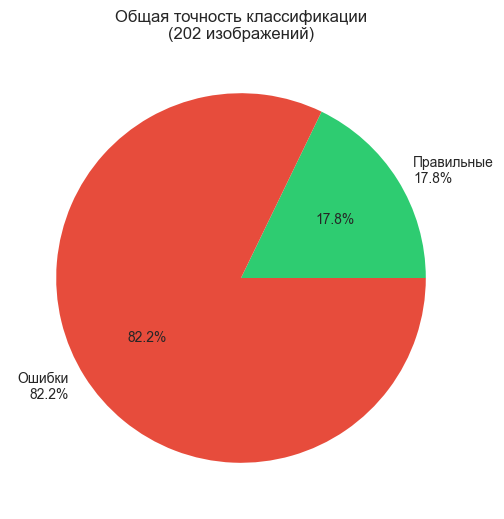


2. Матрица ошибок:


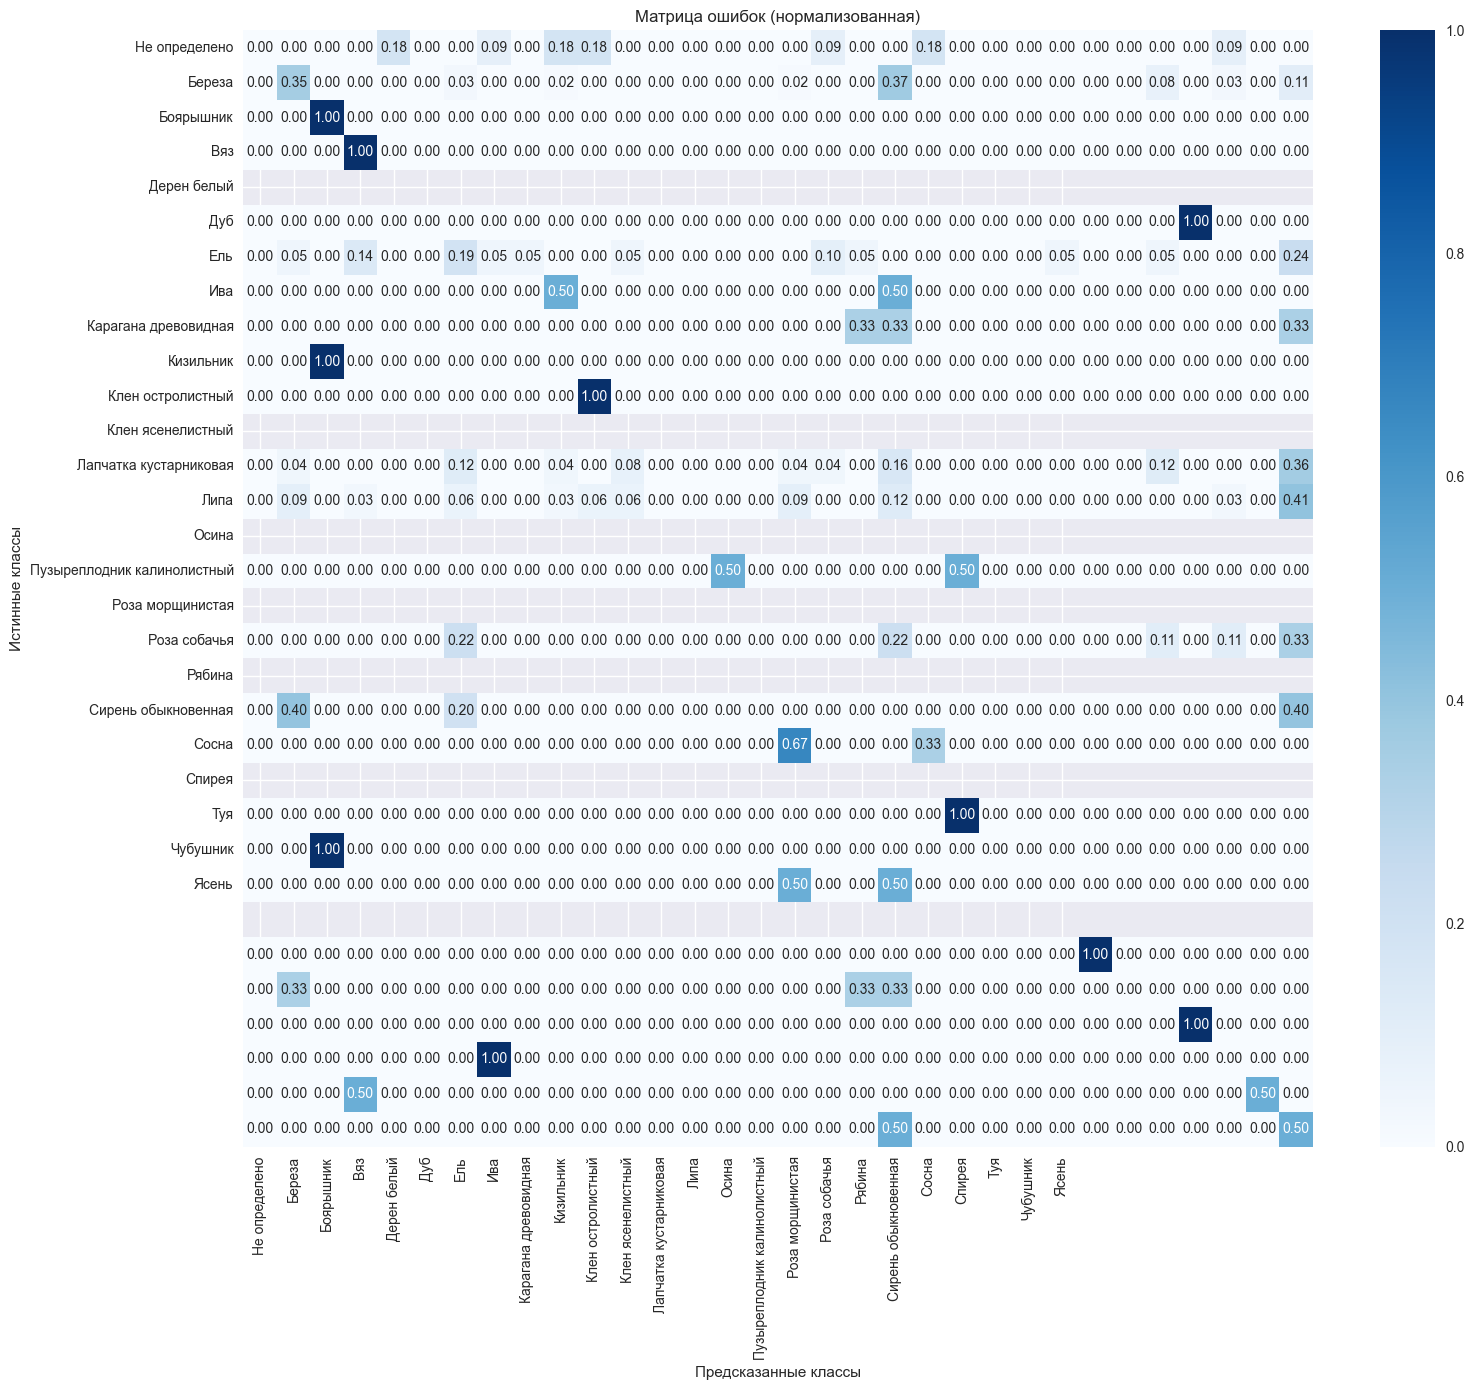


3. Точность по классам:


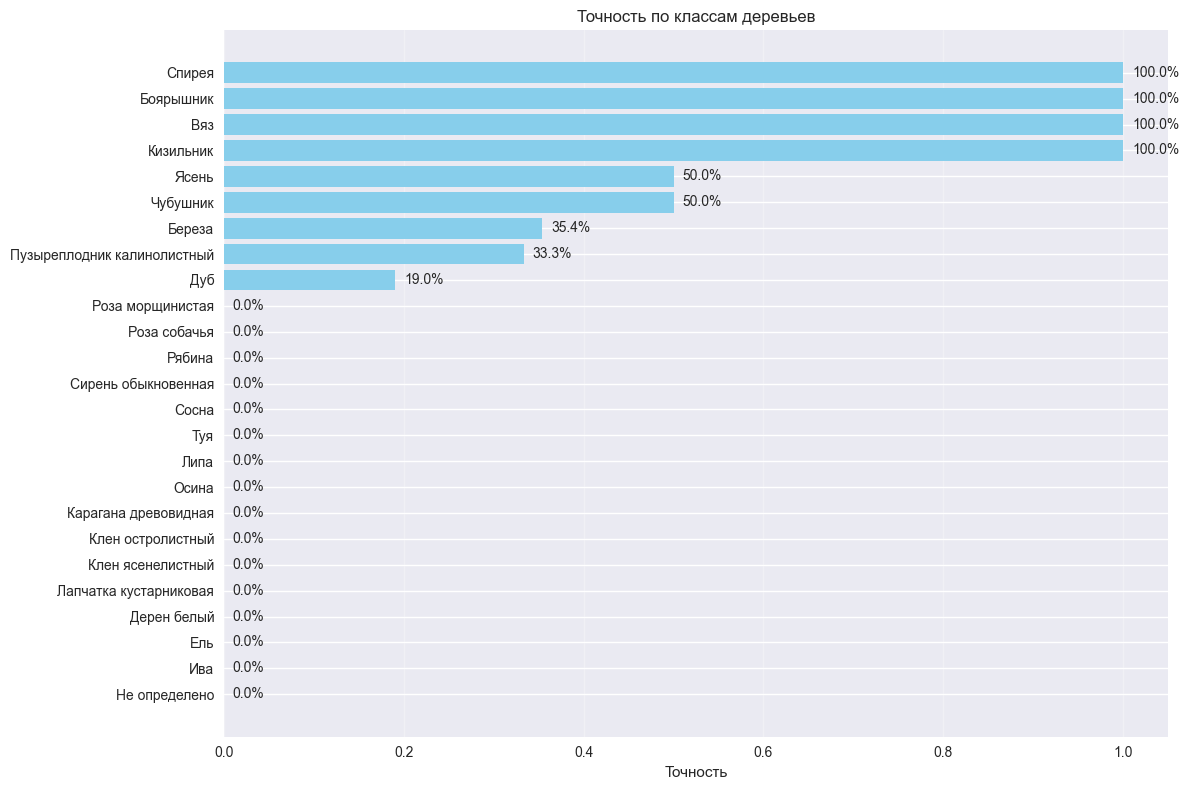


4. Распределение уверенности:


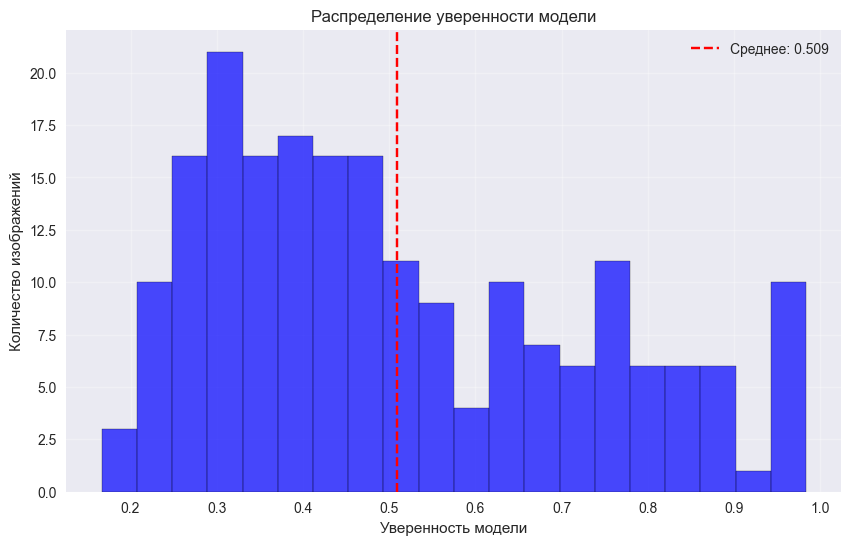


5. Распределение классов:


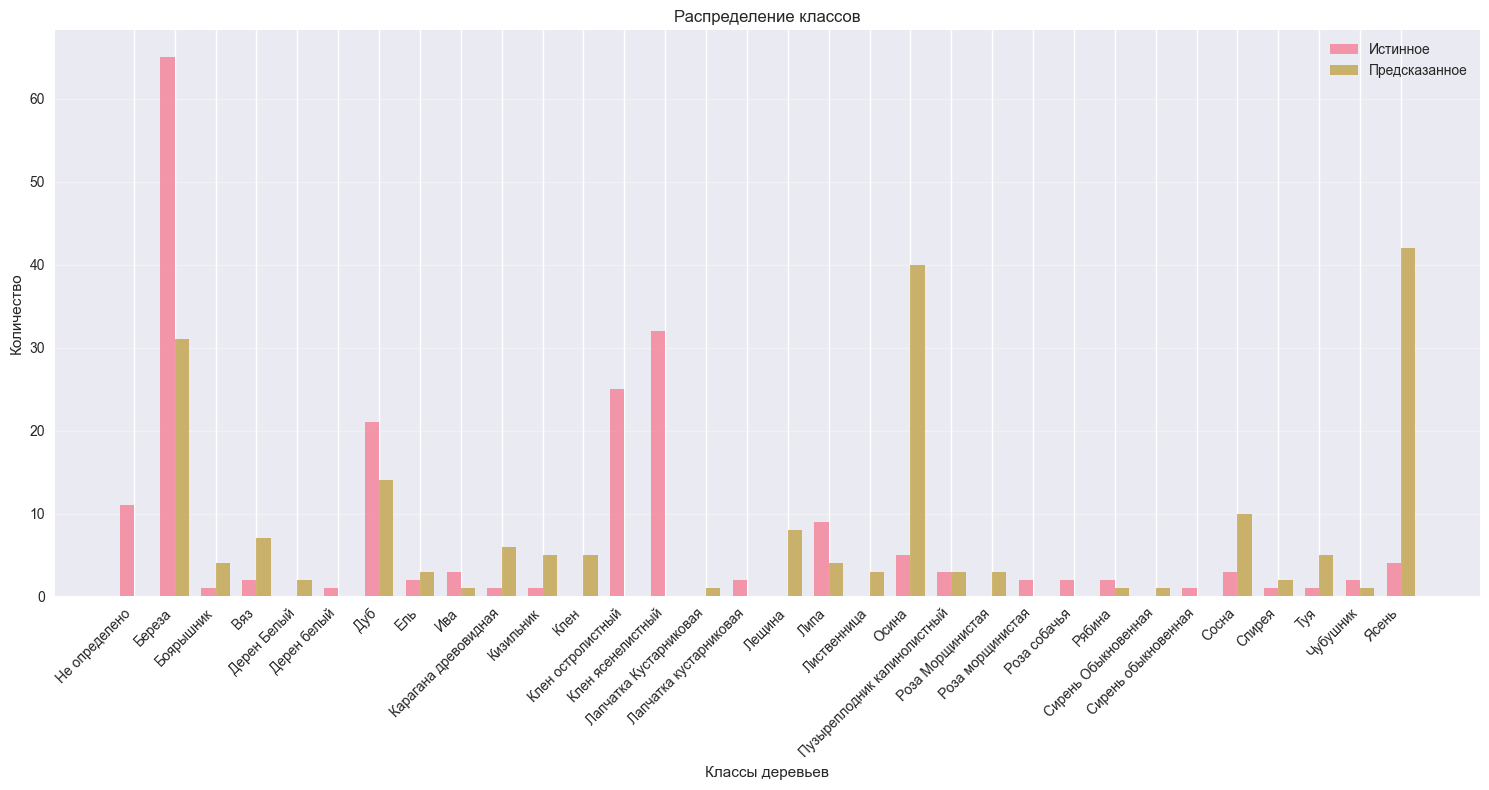


6. Время обработки:


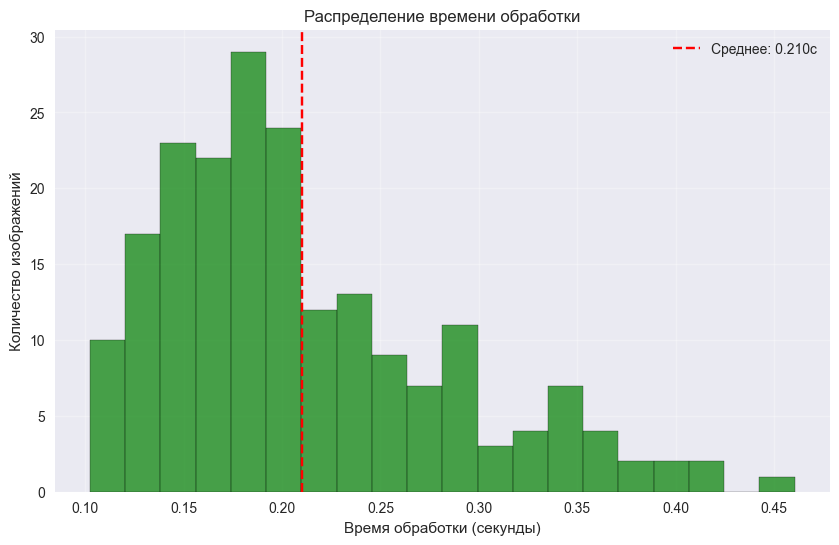


7. Топ ошибок:


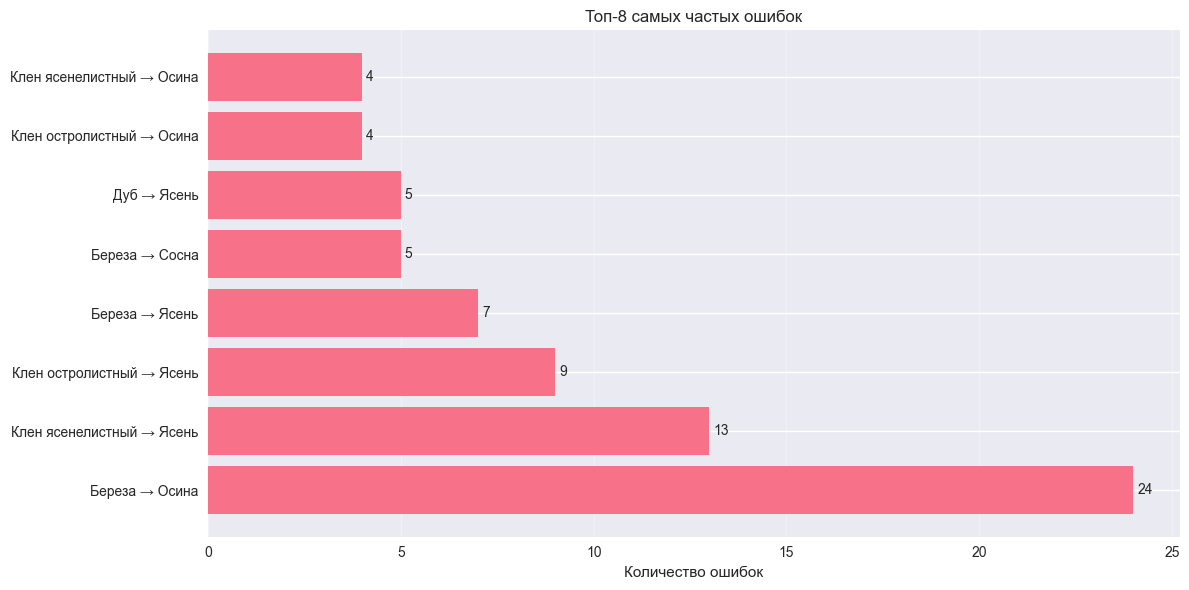


Визуализация завершена!

📄 Генерация детального отчета...
ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ДЕРЕВЬЕВ
Общая точность: 17.82%
Обработано изображений: 202
Уникальных классов: 25
Количество ошибок: 166
Среднее время обработки: 0.210 сек
Средняя уверенность: 0.509
Средняя уверенность (правильные): 0.644
Средняя уверенность (ошибки): 0.480

Топ-5 самых точных классов:
  Боярышник: 100.00%
  Вяз: 100.00%
  Кизильник: 100.00%
  Спирея: 100.00%
  Чубушник: 50.00%

Топ-5 самых проблемных классов:
  Роза собачья: 0.00%
  Сосна: 0.00%
  Сирень обыкновенная: 0.00%
  Рябина: 0.00%
  Туя: 0.00%
✅ Анализ завершен успешно!


In [23]:
analyzer, report = main()

if analyzer is not None:
    print("✅ Анализ завершен успешно!")
else:
    print("❌ Анализ завершен с ошибками")

In [26]:
# Ячейка 20: Сбалансированные метрики для всех атрибутов
def add_balanced_metrics_for_attributes(self):
    """Добавление сбалансированных метрик для всех атрибутов кроме tree_type"""
    
    def calculate_balanced_accuracy(self, y_true, y_pred):
        """Расчет balanced accuracy"""
        from sklearn.metrics import balanced_accuracy_score
        return balanced_accuracy_score(y_true, y_pred)
    
    def calculate_class_weights(self, y_true):
        """Расчет весов классов для несбалансированных данных"""
        from sklearn.utils.class_weight import compute_class_weight
        classes = np.unique(y_true)
        weights = compute_class_weight('balanced', classes=classes, y=y_true)
        return dict(zip(classes, weights))
    
    def calculate_balanced_metrics_for_attribute(self, attribute):
        """Расчет сбалансированных метрик для конкретного атрибута"""
        # Собираем истинные и предсказанные значения для атрибута
        y_true = []
        y_pred = []
        confidences = []
        
        for pred in self.predictions:
            if attribute in pred['classification']:
                class_data = pred['classification'][attribute]
                y_pred.append(class_data['class_label'])
                confidences.append(class_data['confidence'])
                
                # Для true labels используем наиболее вероятное значение из распределения
                # В реальных данных нужно иметь true labels для атрибутов
                # Здесь используем предсказания как пример
                y_true.append(class_data['class_label'])  # В реальности заменить на true labels
        
        if len(y_true) < 2:
            return None
        
        # Базовая accuracy
        accuracy = accuracy_score(y_true, y_pred)
        
        # Balanced accuracy
        balanced_acc = self.calculate_balanced_accuracy(y_true, y_pred)
        
        # Взвешенные метрики
        from sklearn.metrics import precision_recall_fscore_support
        
        # Macro averaging
        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            y_true, y_pred, average='macro', zero_division=0
        )
        
        # Weighted averaging
        precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )
        
        # Micro averaging
        precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
            y_true, y_pred, average='micro', zero_division=0
        )
        
        # Расчет весов классов
        class_weights = self.calculate_class_weights(y_true)
        
        metrics = {
            'attribute': attribute,
            'accuracy': accuracy,
            'balanced_accuracy': balanced_acc,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'precision_weighted': precision_weighted,
            'recall_weighted': recall_weighted,
            'f1_weighted': f1_weighted,
            'precision_micro': precision_micro,
            'recall_micro': recall_micro,
            'f1_micro': f1_micro,
            'n_samples': len(y_true),
            'n_classes': len(np.unique(y_true)),
            'avg_confidence': np.mean(confidences) if confidences else 0,
            'class_weights': class_weights
        }
        
        return metrics
    
    def calculate_all_attributes_balanced_metrics(self):
        """Расчет сбалансированных метрик для всех атрибутов"""
        attributes = self.get_attributes_to_analyze()
        
        metrics_data = []
        for attribute in attributes:
            metrics = self.calculate_balanced_metrics_for_attribute(attribute)
            if metrics is not None:
                metrics_data.append(metrics)
        
        return pd.DataFrame(metrics_data)
    
    def plot_attributes_balanced_metrics_comparison(self):
        """Сравнение сбалансированных метрик по всем атрибутам"""
        metrics_df = self.calculate_all_attributes_balanced_metrics()
        if metrics_df.empty:
            print("Нет данных для анализа!")
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
        
        # 1. Accuracy vs Balanced Accuracy
        x = np.arange(len(metrics_df))
        width = 0.35
        
        ax1.bar(x - width/2, metrics_df['accuracy'], width, 
               label='Standard Accuracy', alpha=0.7, color='lightblue')
        ax1.bar(x + width/2, metrics_df['balanced_accuracy'], width, 
               label='Balanced Accuracy', alpha=0.7, color='lightcoral')
        ax1.set_xlabel('Атрибуты')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Standard vs Balanced Accuracy по атрибутам')
        ax1.set_xticks(x)
        ax1.set_xticklabels(metrics_df['attribute'], rotation=45)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # 2. Разница между Accuracy и Balanced Accuracy
        metrics_df['accuracy_diff'] = abs(metrics_df['accuracy'] - metrics_df['balanced_accuracy'])
        ax2.bar(metrics_df['attribute'], metrics_df['accuracy_diff'], 
               color='orange', alpha=0.7)
        ax2.set_xlabel('Атрибуты')
        ax2.set_ylabel('Разница')
        ax2.set_title('Разница между Standard и Balanced Accuracy')
        ax2.set_xticklabels(metrics_df['attribute'], rotation=45)
        ax2.grid(axis='y', alpha=0.3)
        
        # 3. Weighted F1-Score по атрибутам
        ax3.bar(metrics_df['attribute'], metrics_df['f1_weighted'],
               color='lightgreen', alpha=0.7)
        ax3.set_xlabel('Атрибуты')
        ax3.set_ylabel('Weighted F1-Score')
        ax3.set_title('Weighted F1-Score по атрибутам')
        ax3.set_xticklabels(metrics_df['attribute'], rotation=45)
        ax3.grid(axis='y', alpha=0.3)
        
        # 4. Количество классов по атрибутам
        ax4.bar(metrics_df['attribute'], metrics_df['n_classes'],
               color='wheat', alpha=0.7)
        ax4.set_xlabel('Атрибуты')
        ax4.set_ylabel('Количество классов')
        ax4.set_title('Количество уникальных классов по атрибутам')
        ax4.set_xticklabels(metrics_df['attribute'], rotation=45)
        ax4.grid(axis='y', alpha=0.3)
        
        # Добавление значений на графики
        for ax, values, fmt in [(ax1, metrics_df['accuracy'], '.3f'),
                               (ax1, metrics_df['balanced_accuracy'], '.3f'),
                               (ax2, metrics_df['accuracy_diff'], '.3f'),
                               (ax3, metrics_df['f1_weighted'], '.3f'),
                               (ax4, metrics_df['n_classes'], 'd')]:
            for i, v in enumerate(values):
                if ax == ax1 and fmt == '.3f' and i == 0:  # Только для первого набора в ax1
                    ax.text(i - width/2, v + 0.01, f'{v:{fmt}}', ha='center', va='bottom', fontsize=8)
                elif ax == ax1 and fmt == '.3f':  # Для второго набора в ax1
                    ax.text(i + width/2, v + 0.01, f'{v:{fmt}}', ha='center', va='bottom', fontsize=8)
                else:
                    ax.text(i, v + 0.01, f'{v:{fmt}}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        return metrics_df
    
    def plot_attributes_class_balance_analysis(self):
        """Анализ сбалансированности классов для каждого атрибута"""
        attributes = self.get_attributes_to_analyze()
        
        n_attributes = len(attributes)
        n_cols = 2
        n_rows = (n_attributes + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        if n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        
        balance_stats = []
        
        for i, attribute in enumerate(attributes):
            if i < len(axes):
                # Собираем распределение значений для атрибута
                predictions = []
                for pred in self.predictions:
                    if attribute in pred['classification']:
                        class_data = pred['classification'][attribute]
                        predictions.append(class_data['class_label'])
                
                if predictions:
                    pred_counts = Counter(predictions)
                    classes, counts = zip(*pred_counts.most_common())
                    
                    # Расчет баланса
                    balance_ratio = min(counts) / max(counts) if counts else 0
                    total_samples = len(predictions)
                    
                    # Визуализация
                    bars = axes[i].bar(classes, counts, color='skyblue', edgecolor='black')
                    axes[i].set_title(f'{attribute}\nБаланс: {balance_ratio:.2f}')
                    axes[i].tick_params(axis='x', rotation=45)
                    axes[i].grid(axis='y', alpha=0.3)
                    
                    # Добавление значений
                    for bar, count in zip(bars, counts):
                        height = bar.get_height()
                        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                                    f'{count}', ha='center', va='bottom', fontsize=8)
                    
                    balance_stats.append({
                        'attribute': attribute,
                        'balance_ratio': balance_ratio,
                        'n_classes': len(classes),
                        'total_samples': total_samples,
                        'most_common': classes[0],
                        'most_common_count': counts[0],
                        'least_common': classes[-1],
                        'least_common_count': counts[-1]
                    })
        
        # Скрываем пустые subplots
        for i in range(len(attributes), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Анализ статистики баланса
        if balance_stats:
            balance_df = pd.DataFrame(balance_stats)
            print("\n📊 АНАЛИЗ СБАЛАНСИРОВАННОСТИ ПО АТРИБУТАМ:")
            for _, row in balance_df.iterrows():
                status = "🟢" if row['balance_ratio'] > 0.5 else "🟡" if row['balance_ratio'] > 0.2 else "🔴"
                print(f"  {status} {row['attribute']}: баланс {row['balance_ratio']:.2f} "
                      f"({row['n_classes']} классов, {row['total_samples']} образцов)")
            
            return balance_df
        return None
    
    def plot_attributes_metrics_correlation(self):
        """Корреляция между метриками и характеристиками атрибутов"""
        metrics_df = self.calculate_all_attributes_balanced_metrics()
        if metrics_df.empty:
            return
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Balanced Accuracy vs Количество классов
        ax1.scatter(metrics_df['n_classes'], metrics_df['balanced_accuracy'], 
                   s=100, alpha=0.7)
        ax1.set_xlabel('Количество классов')
        ax1.set_ylabel('Balanced Accuracy')
        ax1.set_title('Balanced Accuracy vs Сложность атрибута')
        ax1.grid(alpha=0.3)
        
        # Добавляем названия атрибутов
        for i, row in metrics_df.iterrows():
            ax1.annotate(row['attribute'], (row['n_classes'], row['balanced_accuracy']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        # 2. Balanced Accuracy vs Средняя уверенность
        ax2.scatter(metrics_df['avg_confidence'], metrics_df['balanced_accuracy'],
                   s=100, alpha=0.7, color='red')
        ax2.set_xlabel('Средняя уверенность')
        ax2.set_ylabel('Balanced Accuracy')
        ax2.set_title('Balanced Accuracy vs Уверенность модели')
        ax2.grid(alpha=0.3)
        
        for i, row in metrics_df.iterrows():
            ax2.annotate(row['attribute'], (row['avg_confidence'], row['balanced_accuracy']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        # 3. Разница Accuracy vs Количество классов
        ax3.scatter(metrics_df['n_classes'], metrics_df['accuracy_diff'],
                   s=100, alpha=0.7, color='green')
        ax3.set_xlabel('Количество классов')
        ax3.set_ylabel('Разница Accuracy')
        ax3.set_title('Влияние дисбаланса на точность')
        ax3.grid(alpha=0.3)
        
        for i, row in metrics_df.iterrows():
            ax3.annotate(row['attribute'], (row['n_classes'], row['accuracy_diff']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        # 4. Heatmap корреляций между метриками
        correlation_cols = ['accuracy', 'balanced_accuracy', 'f1_weighted', 
                          'n_classes', 'avg_confidence', 'accuracy_diff']
        corr_matrix = metrics_df[correlation_cols].corr()
        
        im = ax4.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
        ax4.set_xticks(range(len(correlation_cols)))
        ax4.set_yticks(range(len(correlation_cols)))
        ax4.set_xticklabels(['Acc', 'BalAcc', 'F1-W', 'N-Cls', 'Conf', 'Diff'], rotation=45)
        ax4.set_yticklabels(['Acc', 'BalAcc', 'F1-W', 'N-Cls', 'Conf', 'Diff'])
        ax4.set_title('Корреляция метрик атрибутов')
        
        # Добавляем значения в ячейки
        for i in range(len(correlation_cols)):
            for j in range(len(correlation_cols)):
                text = ax4.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                              ha="center", va="center", color="black")
        
        plt.colorbar(im, ax=ax4)
        plt.tight_layout()
        plt.show()
        
        # Анализ корреляций
        print("\n🔗 ЗНАЧИМЫЕ КОРРЕЛЯЦИИ:")
        strong_correlations = []
        for i in range(len(correlation_cols)):
            for j in range(i+1, len(correlation_cols)):
                corr = corr_matrix.iloc[i, j]
                if abs(corr) > 0.5:
                    strong_correlations.append({
                        'metric1': correlation_cols[i],
                        'metric2': correlation_cols[j],
                        'correlation': corr
                    })
        
        for corr in strong_correlations:
            direction = "положительная" if corr['correlation'] > 0 else "отрицательная"
            print(f"  • {corr['metric1']} ↔ {corr['metric2']}: {corr['correlation']:.2f} ({direction})")
    
    def plot_attributes_performance_matrix(self):
        """Матрица производительности по атрибутам"""
        metrics_df = self.calculate_all_attributes_balanced_metrics()
        if metrics_df.empty:
            return
        
        # Создаем матрицу для heatmap
        performance_metrics = ['accuracy', 'balanced_accuracy', 'f1_weighted', 'avg_confidence']
        performance_df = metrics_df.set_index('attribute')[performance_metrics]
        
        # Нормализуем значения для лучшей визуализации
        normalized_df = (performance_df - performance_df.min()) / (performance_df.max() - performance_df.min())
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1. Heatmap нормализованных значений
        im1 = ax1.imshow(normalized_df.values, cmap='RdYlGn', aspect='auto')
        ax1.set_xticks(range(len(performance_metrics)))
        ax1.set_yticks(range(len(normalized_df)))
        ax1.set_xticklabels(['Accuracy', 'Balanced\nAccuracy', 'Weighted\nF1-Score', 'Average\nConfidence'])
        ax1.set_yticklabels(normalized_df.index)
        ax1.set_title('Нормализованная производительность атрибутов\n(зеленый = лучше)')
        
        # Добавляем значения
        for i in range(len(normalized_df)):
            for j in range(len(performance_metrics)):
                ax1.text(j, i, f'{performance_df.iloc[i, j]:.3f}',
                        ha="center", va="center", color="black", fontsize=8)
        
        # 2. Ранжирование атрибутов по Balanced Accuracy
        sorted_df = metrics_df.sort_values('balanced_accuracy', ascending=True)
        y_pos = np.arange(len(sorted_df))
        
        bars = ax2.barh(y_pos, sorted_df['balanced_accuracy'], color='lightcoral', alpha=0.7)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(sorted_df['attribute'])
        ax2.set_xlabel('Balanced Accuracy')
        ax2.set_title('Ранжирование атрибутов по Balanced Accuracy')
        ax2.grid(axis='x', alpha=0.3)
        
        # Добавляем значения
        for bar, acc in zip(bars, sorted_df['balanced_accuracy']):
            ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{acc:.3f}', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # Анализ лучших/худших атрибутов
        print("\n🏆 ЛУЧШИЕ АТРИБУТЫ ПО BALANCED ACCURACY:")
        top_attributes = metrics_df.nlargest(3, 'balanced_accuracy')
        for _, row in top_attributes.iterrows():
            print(f"  • {row['attribute']}: {row['balanced_accuracy']:.3f} "
                  f"(Accuracy: {row['accuracy']:.3f}, F1: {row['f1_weighted']:.3f})")
        
        print("\n⚠️  АТРИБУТЫ, ТРЕБУЮЩИЕ ВНИМАНИЯ:")
        bottom_attributes = metrics_df.nsmallest(3, 'balanced_accuracy')
        for _, row in bottom_attributes.iterrows():
            print(f"  • {row['attribute']}: {row['balanced_accuracy']:.3f} "
                  f"(Accuracy: {row['accuracy']:.3f}, F1: {row['f1_weighted']:.3f})")
    
    def generate_attributes_balanced_report(self):
        """Генерация отчета по сбалансированным метрикам для атрибутов"""
        metrics_df = self.calculate_all_attributes_balanced_metrics()
        if metrics_df.empty:
            print("Нет данных для отчета!")
            return
        
        print("=" * 80)
        print("ОТЧЕТ ПО СБАЛАНСИРОВАННЫМ МЕТРИКАМ ДЛЯ АТРИБУТОВ")
        print("=" * 80)
        
        # Общая статистика
        avg_balanced_acc = metrics_df['balanced_accuracy'].mean()
        avg_accuracy = metrics_df['accuracy'].mean()
        avg_f1 = metrics_df['f1_weighted'].mean()
        
        print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
        print(f"  • Средний Balanced Accuracy: {avg_balanced_acc:.3f}")
        print(f"  • Средний Standard Accuracy: {avg_accuracy:.3f}")
        print(f"  • Средний Weighted F1-Score: {avg_f1:.3f}")
        print(f"  • Количество атрибутов: {len(metrics_df)}")
        
        # Анализ дисбаланса
        avg_accuracy_diff = metrics_df['accuracy_diff'].mean()
        print(f"\n⚖️  АНАЛИЗ ДИСБАЛАНСА:")
        print(f"  • Средняя разница Accuracy-Balanced: {avg_accuracy_diff:.3f}")
        
        if avg_accuracy_diff < 0.05:
            print("  • 🟢 Общий дисбаланс незначительный")
        elif avg_accuracy_diff < 0.1:
            print("  • 🟡 Умеренный дисбаланс в данных")
        else:
            print("  • 🔴 Значительный дисбаланс в данных")
        
        # Рекомендации по атрибутам
        print(f"\n💡 РЕКОМЕНДАЦИИ:")
        
        # Лучшие атрибуты
        best_attr = metrics_df.nlargest(1, 'balanced_accuracy').iloc[0]
        print(f"  • Лучший атрибут: '{best_attr['attribute']}' "
              f"(Balanced Acc: {best_attr['balanced_accuracy']:.3f})")
        
        # Атрибуты с наибольшим дисбалансом
        worst_imbalance = metrics_df.nlargest(1, 'accuracy_diff').iloc[0]
        if worst_imbalance['accuracy_diff'] > 0.1:
            print(f"  • Наибольший дисбаланс: '{worst_imbalance['attribute']}' "
                  f"(разница: {worst_imbalance['accuracy_diff']:.3f})")
        
        # Атрибуты с низкой точностью
        low_accuracy = metrics_df[metrics_df['balanced_accuracy'] < 0.7]
        if not low_accuracy.empty:
            print(f"  • Атрибуты с низкой точностью (<0.7): {', '.join(low_accuracy['attribute'].tolist())}")
        
        print("=" * 80)
    
    def create_attributes_balanced_dashboard(self):
        """Комплексная дашборд для сбалансированных метрик атрибутов"""
        print("⚖️ ЗАПУСК АНАЛИЗА СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ")
        print("=" * 70)
        
        # 1. Сравнение метрик по атрибутам
        print("\n1. 📊 СРАВНЕНИЕ МЕТРИК ПО АТРИБУТАМ")
        metrics_df = self.plot_attributes_balanced_metrics_comparison()
        
        # 2. Анализ сбалансированности
        print("\n2. 📈 АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ")
        balance_df = self.plot_attributes_class_balance_analysis()
        
        # 3. Корреляционный анализ
        print("\n3. 🔗 КОРРЕЛЯЦИИ МЕТРИК")
        self.plot_attributes_metrics_correlation()
        
        # 4. Матрица производительности
        print("\n4. 🏆 МАТРИЦА ПРОИЗВОДИТЕЛЬНОСТИ")
        self.plot_attributes_performance_matrix()
        
        # 5. Отчет
        print("\n5. 📋 ДЕТАЛЬНЫЙ ОТЧЕТ")
        self.generate_attributes_balanced_report()
        
        print("\n✅ АНАЛИЗ СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ ЗАВЕРШЕН")
        
        return {
            'metrics': metrics_df,
            'balance': balance_df
        }

    # Добавляем методы к классу
    TreeClassificationAnalyzer.calculate_balanced_accuracy = calculate_balanced_accuracy
    TreeClassificationAnalyzer.calculate_class_weights = calculate_class_weights
    TreeClassificationAnalyzer.calculate_balanced_metrics_for_attribute = calculate_balanced_metrics_for_attribute
    TreeClassificationAnalyzer.calculate_all_attributes_balanced_metrics = calculate_all_attributes_balanced_metrics
    TreeClassificationAnalyzer.plot_attributes_balanced_metrics_comparison = plot_attributes_balanced_metrics_comparison
    TreeClassificationAnalyzer.plot_attributes_class_balance_analysis = plot_attributes_class_balance_analysis
    TreeClassificationAnalyzer.plot_attributes_metrics_correlation = plot_attributes_metrics_correlation
    TreeClassificationAnalyzer.plot_attributes_performance_matrix = plot_attributes_performance_matrix
    TreeClassificationAnalyzer.generate_attributes_balanced_report = generate_attributes_balanced_report
    TreeClassificationAnalyzer.create_attributes_balanced_dashboard = create_attributes_balanced_dashboard

add_balanced_metrics_for_attributes(TreeClassificationAnalyzer)
print("Методы сбалансированных метрик для атрибутов добавлены успешно!")

Методы сбалансированных метрик для атрибутов добавлены успешно!


Функция анализа сбалансированных метрик для атрибутов готова!
⚖️ ЗАПУСК АНАЛИЗА СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ
⚖️ ЗАПУСК АНАЛИЗА СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ

1. 📊 СРАВНЕНИЕ МЕТРИК ПО АТРИБУТАМ


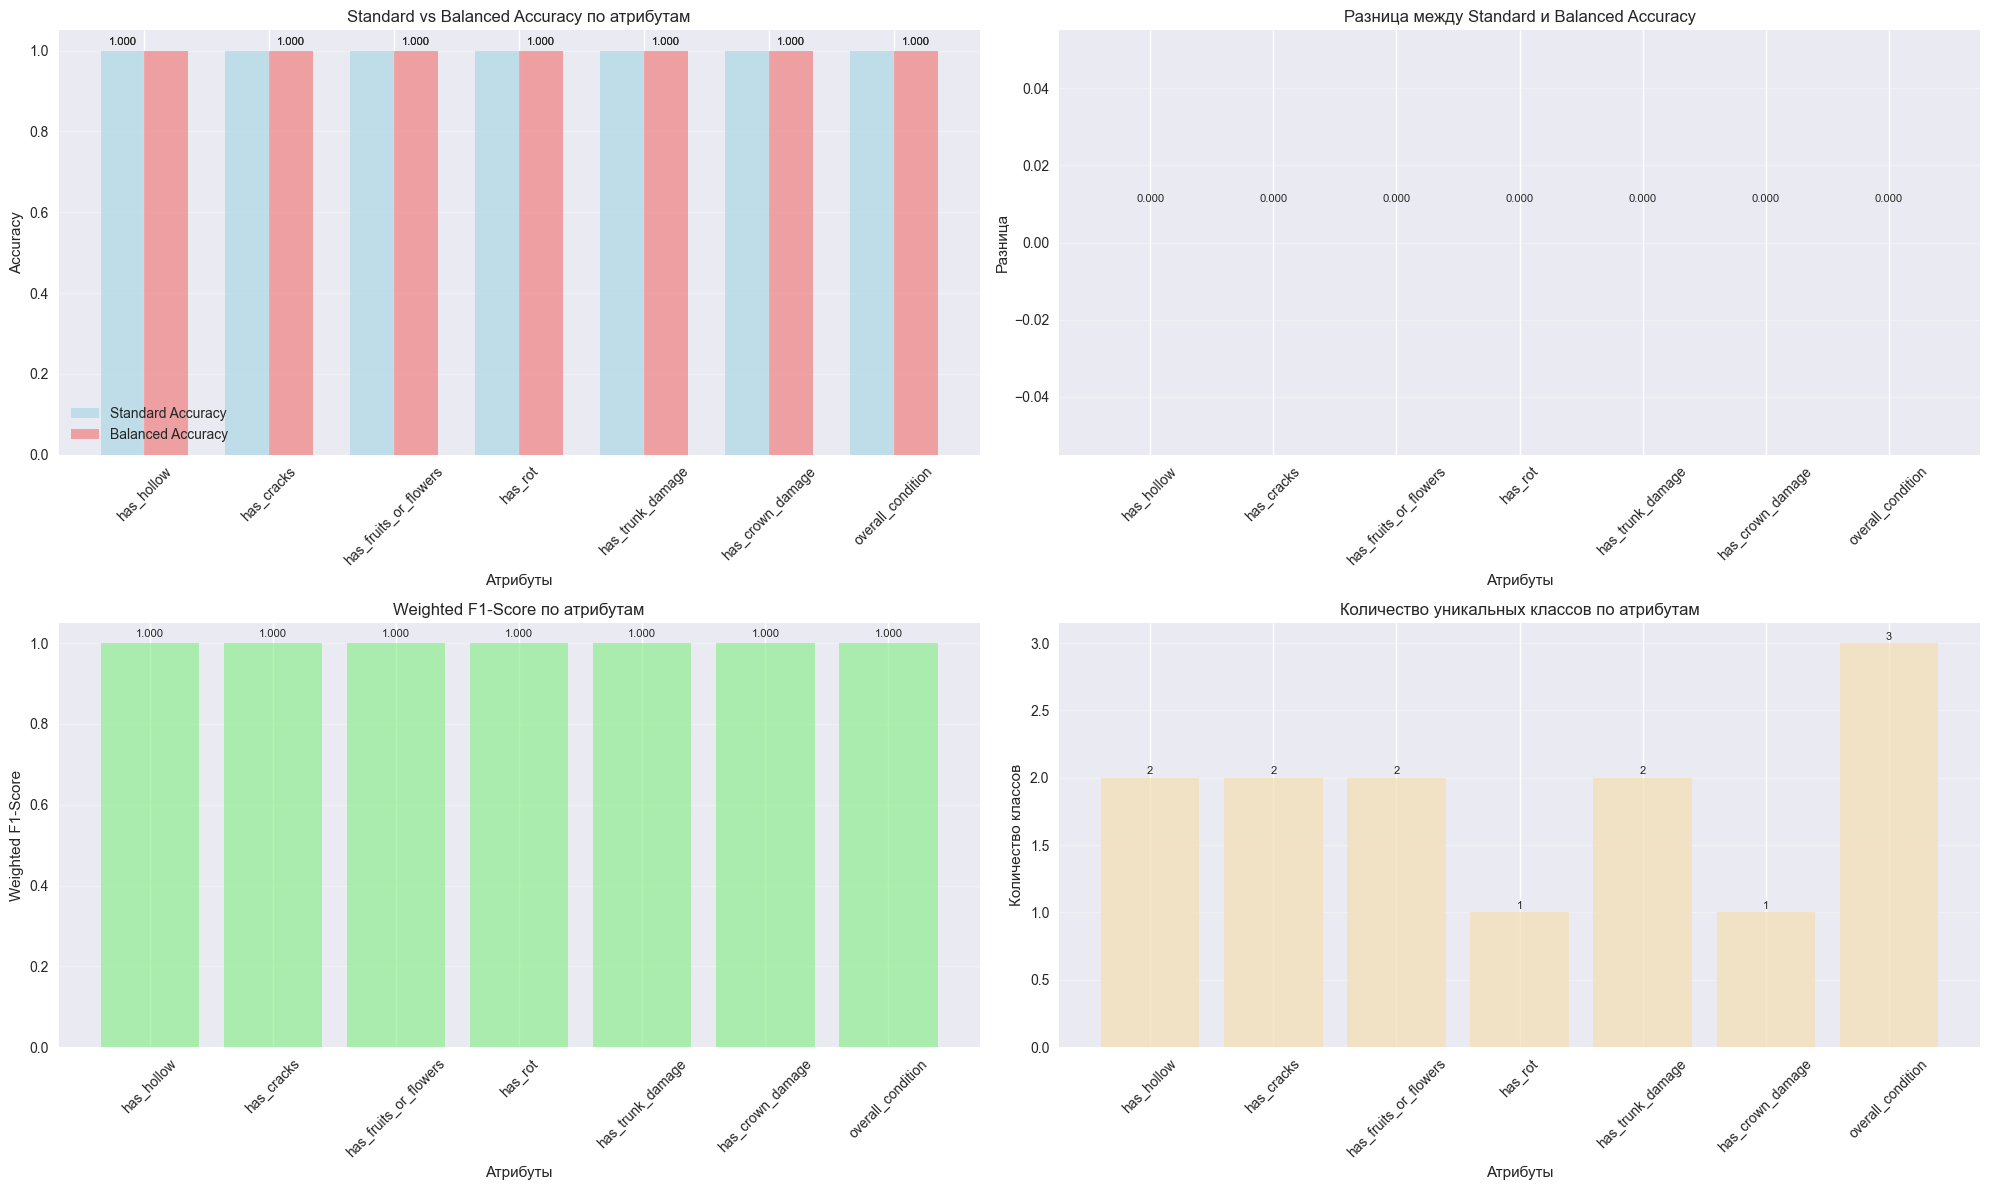


2. 📈 АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ


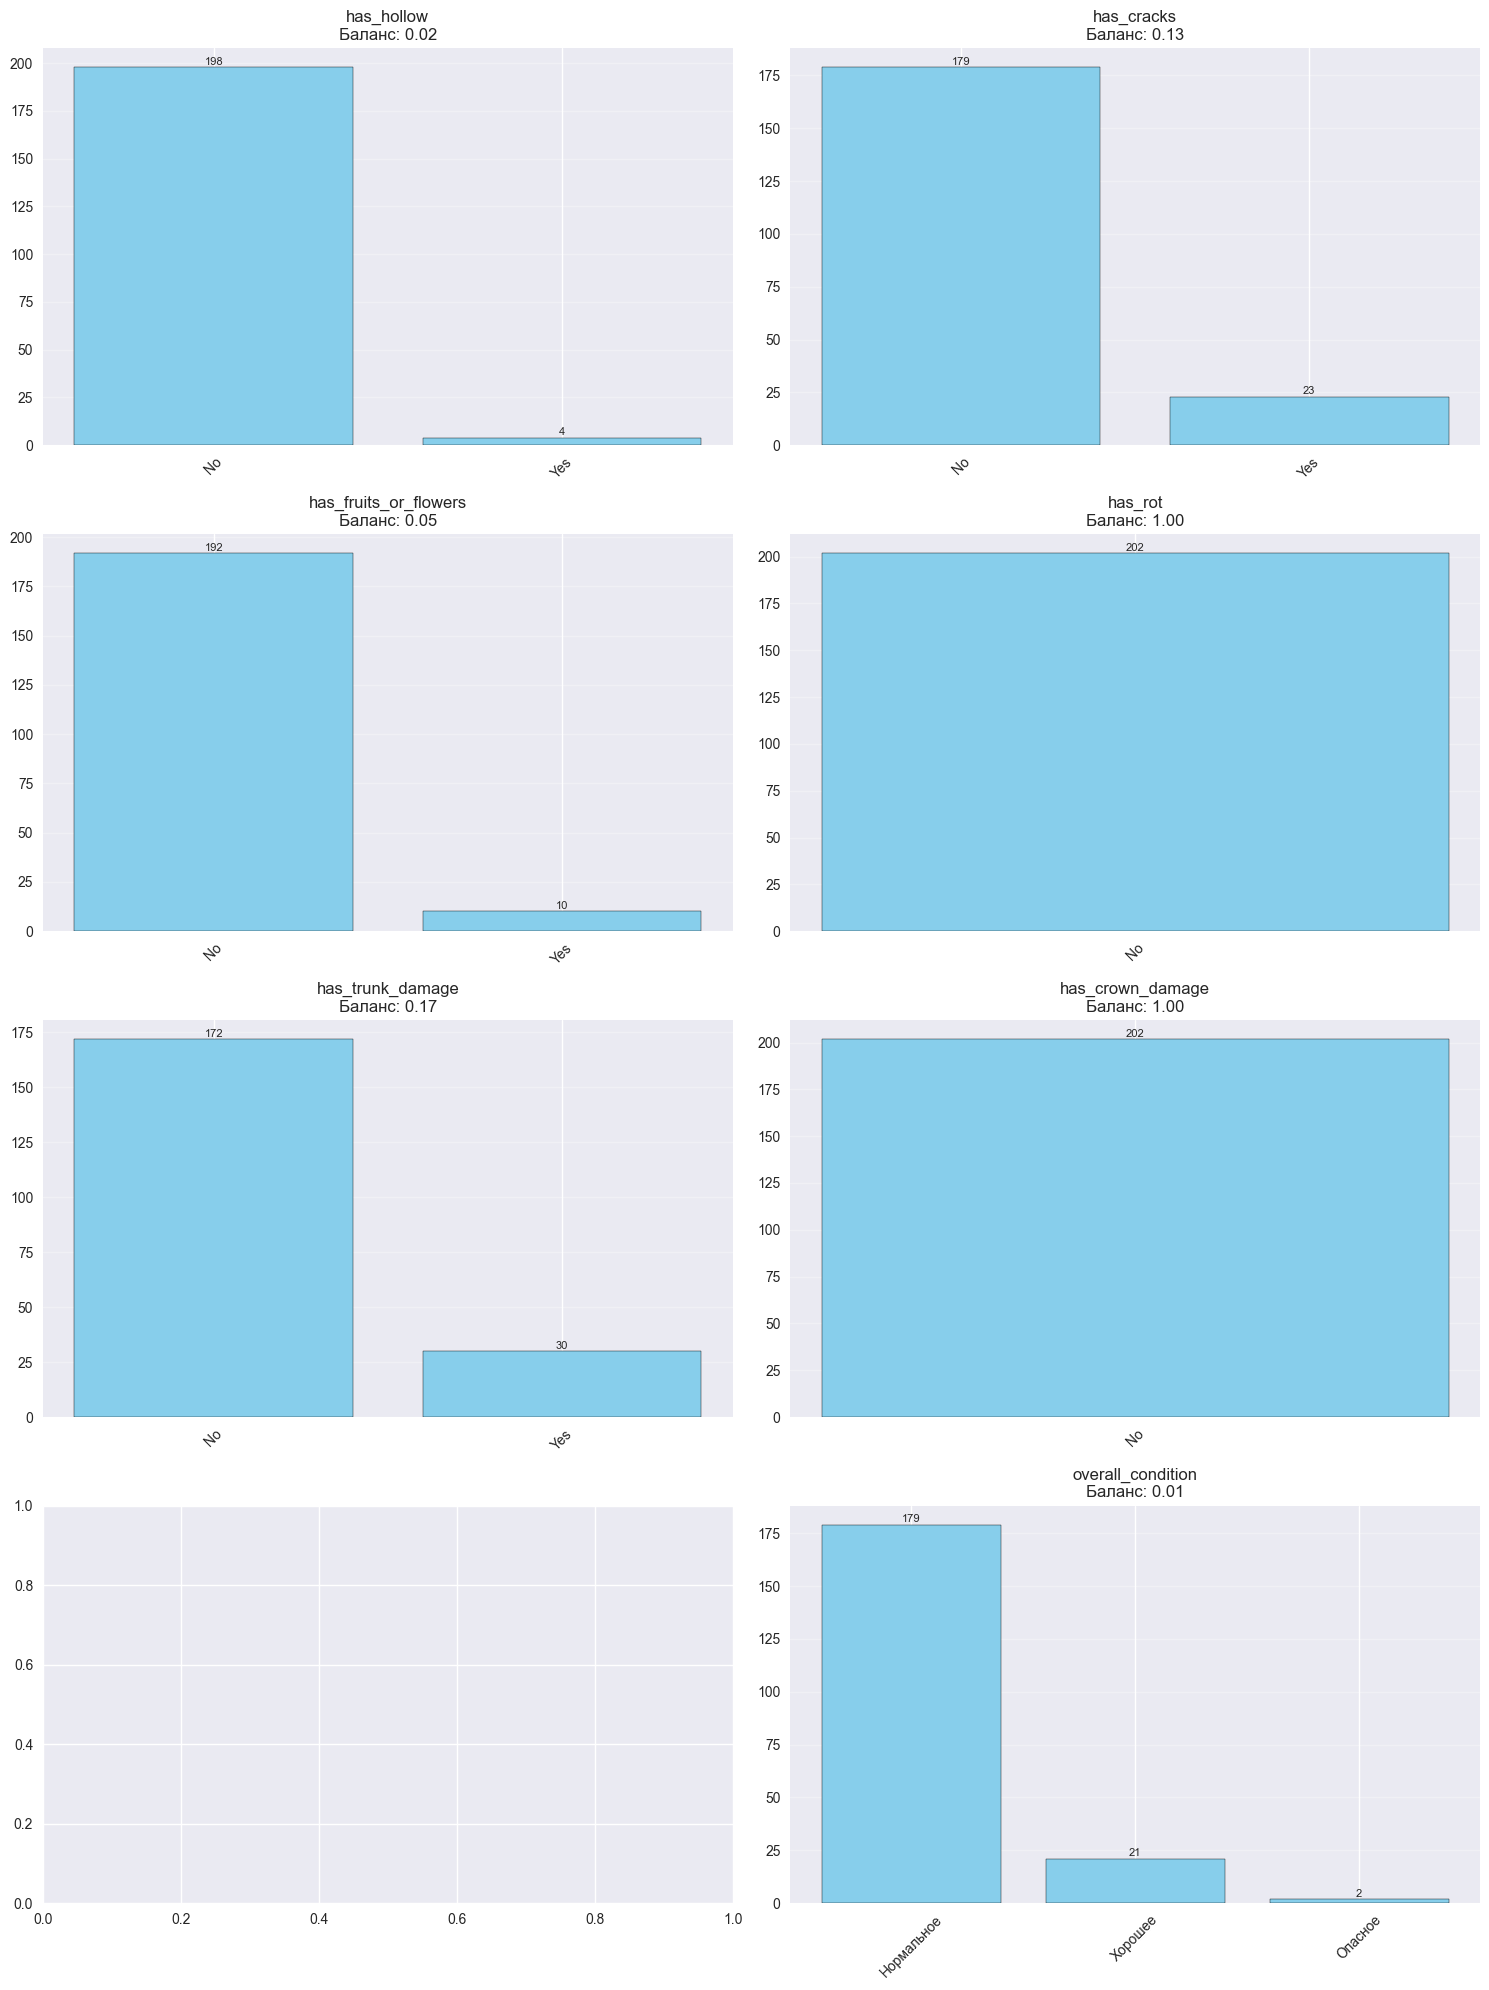


📊 АНАЛИЗ СБАЛАНСИРОВАННОСТИ ПО АТРИБУТАМ:
  🔴 has_hollow: баланс 0.02 (2 классов, 202 образцов)
  🔴 has_cracks: баланс 0.13 (2 классов, 202 образцов)
  🔴 has_fruits_or_flowers: баланс 0.05 (2 классов, 202 образцов)
  🟢 has_rot: баланс 1.00 (1 классов, 202 образцов)
  🔴 has_trunk_damage: баланс 0.17 (2 классов, 202 образцов)
  🟢 has_crown_damage: баланс 1.00 (1 классов, 202 образцов)
  🔴 overall_condition: баланс 0.01 (3 классов, 202 образцов)

3. 🔗 КОРРЕЛЯЦИИ МЕТРИК


KeyError: 'accuracy_diff'

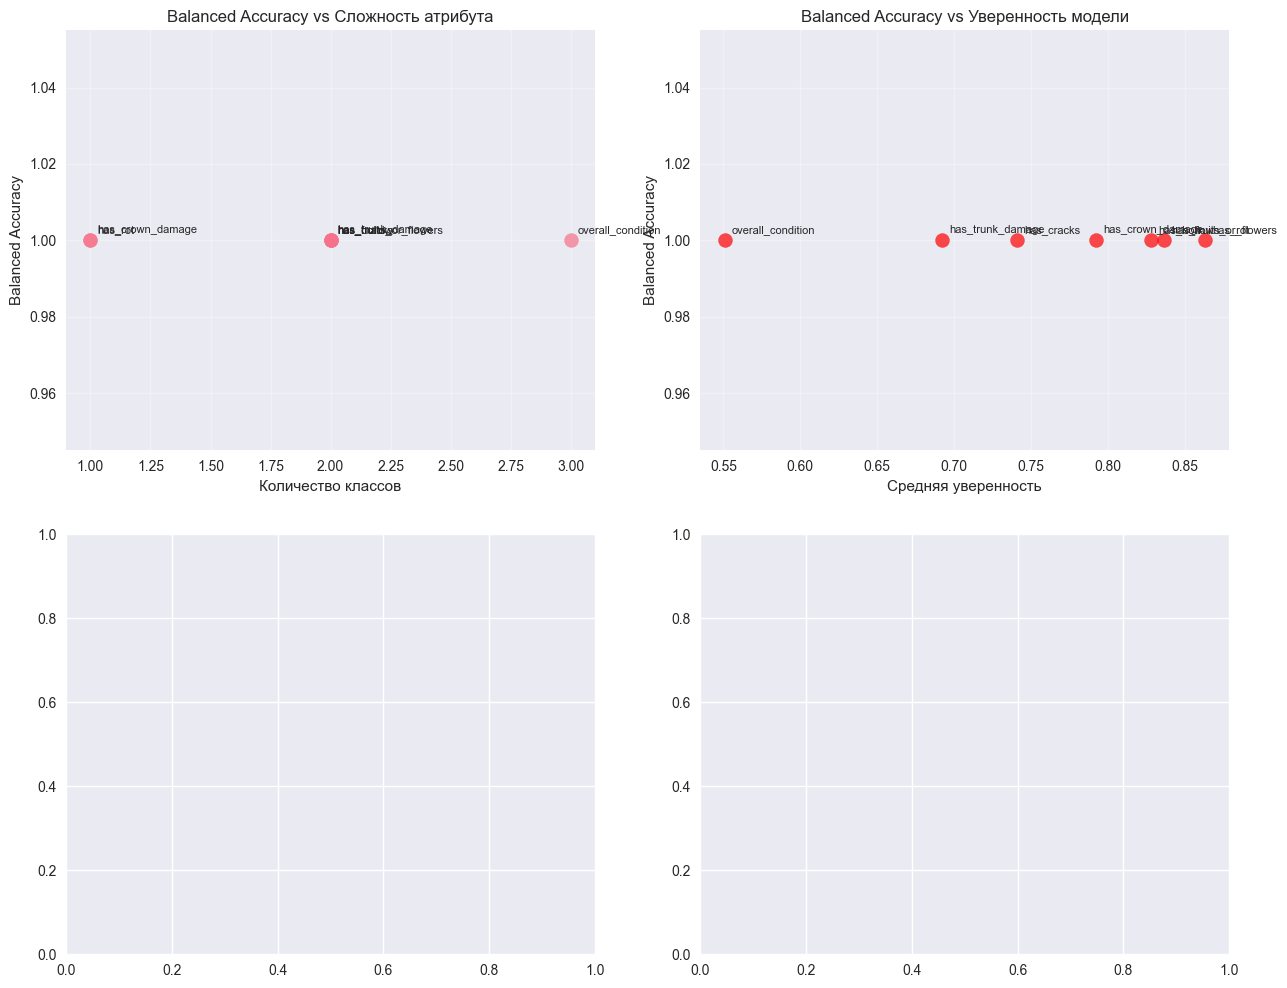

In [28]:
# Ячейка 21: Запуск анализа сбалансированных метрик для атрибутов
def run_attributes_balanced_analysis(analyzer):
    """
    Запуск комплексного анализа сбалансированных метрик для всех атрибутов
    """
    print("⚖️ ЗАПУСК АНАЛИЗА СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ")
    print("=" * 70)
    
    balanced_results = analyzer.create_attributes_balanced_dashboard()
    
    print("\n🎉 АНАЛИЗ СБАЛАНСИРОВАННЫХ МЕТРИК ДЛЯ АТРИБУТОВ ЗАВЕРШЕН!")
    
    return balanced_results

print("Функция анализа сбалансированных метрик для атрибутов готова!")

attributes_balanced_results = run_attributes_balanced_analysis(analyzer)